# Structural Analysis of the zinc Dataset

The ZINC dataset is a collection of molecular graphs where each molecule is associated with a single continuous target value, making it a graph-level regression task.

We use this dataset to evaluate the performance of graph neural networks across different depths, focusing on the same phenomena studied throughout this project, such as the effect of increasing layers and the presence of over-squashing.

In [1]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import ZINC
from torch_geometric.utils import to_networkx, degree
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.loader import DataLoader

from torch.utils.data import random_split

import networkx as nx

In [2]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("../../results/plots/zinc", exist_ok=True)
os.makedirs("../../results/tables/zinc", exist_ok=True)

## Dataset

In [3]:
dataset = ZINC(root="../../data/zinc", subset=True)

print(len(dataset))
print(dataset.num_features)

10000
1


## Models

In [4]:
sys.path.append(os.path.abspath("../.."))

from src.models.graph_regression import GCN, GraphSAGE, GAT

from src.training.train import train_graph_regression
from src.training.evaluate import evaluate_graph_regression

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
out_dim = 1 # regression

hidden_dim = 64
epochs = 30
lr = 0.01
weight_decay = 0.0005
dropout = 0.2

layer_values = [2, 4, 6, 8]
seeds = [0, 7, 37, 42]

results = {m: {"layers": [], "mae_mean": [], "mae_std": [], "time": []} for m in models.keys()}
history = {}

num_graphs = len(dataset)
train_size = int(0.8 * num_graphs)
val_size = int(0.1 * num_graphs)
test_size = num_graphs - train_size - val_size

batch_size = 128

num_atom_types = int(dataset.data.x.max()) + 1

for model_name, Model in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    history[model_name] = {}

    for num_layers in layer_values:
        history[model_name][num_layers] = {}

        mae_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            split_generator = torch.Generator().manual_seed(seed)

            train_dataset, val_dataset, test_dataset = random_split(
                dataset,
                [train_size, val_size, test_size],
                generator=split_generator
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True,
                generator=torch.Generator().manual_seed(seed),
                num_workers=4,
                pin_memory=True
            )

            val_loader = DataLoader(
                val_dataset,
                batch_size=batch_size,
                shuffle=False,
                num_workers=4,
                pin_memory=True
            )

            test_loader = DataLoader(
                test_dataset,
                batch_size=batch_size,
                shuffle=False,
                num_workers=4,
                pin_memory=True
            )

            model = Model(in_dim, hidden_dim, out_dim, num_layers, dropout, use_embedding=True, num_atom_types=num_atom_types).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            start = time.time()

            hist = train_graph_regression(
                model,
                train_loader,
                val_loader,
                optimizer,
                device,
                epochs=epochs,
            )
            history[model_name][num_layers][seed] = hist

            elapsed = time.time() - start

            mae = evaluate_graph_regression(
                model,
                test_loader,
                device,
            )

            mae_runs.append(mae)
            time_runs.append(elapsed)

        # estadísticas
        mae_mean = np.mean(mae_runs)
        mae_std = np.std(mae_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["mae_mean"].append(mae_mean)
        results[model_name]["mae_std"].append(mae_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"MAE: {mae_mean:.4f} ± {mae_std:.4f}"
        )

Running on cuda

Running experiments for GCN


/tmp/ipykernel_194919/1562845641.py:32: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_atom_types = int(dataset.data.x.max()) + 1
100% 30/30 [02:05<00:00,  4.20s/it]
100% 30/30 [02:23<00:00,  4.78s/it]
100% 30/30 [02:26<00:00,  4.87s/it]
100% 30/30 [02:28<00:00,  4.94s/it]


Layers: 2 | MAE: 0.0051 ± 0.0003


100% 30/30 [03:26<00:00,  6.90s/it]
100% 30/30 [03:28<00:00,  6.94s/it]
100% 30/30 [03:38<00:00,  7.27s/it]
100% 30/30 [03:35<00:00,  7.17s/it]


Layers: 4 | MAE: 0.0053 ± 0.0004


...

Layers: 4 | MAE: 0.0053 ± 0.0004


100% 30/30 [04:37<00:00,  9.26s/it]
100% 30/30 [04:17<00:00,  8.57s/it]
100% 30/30 [04:09<00:00,  8.31s/it]
100% 30/30 [04:28<00:00,  8.94s/it]


Layers: 6 | MAE: 0.0075 ± 0.0024


100% 30/30 [05:36<00:00, 11.22s/it]
100% 30/30 [05:31<00:00, 11.03s/it]
100% 30/30 [05:30<00:00, 11.03s/it]
100% 30/30 [05:28<00:00, 10.95s/it]


Layers: 8 | MAE: 0.0116 ± 0.0010


In [6]:
def plot_by_model(history, model_name):

    layers_list = sorted(history[model_name].keys())

    fig, axs = plt.subplots(2, len(layers_list), figsize=(5 * len(layers_list), 8))

    for i, num_layers in enumerate(layers_list):

        seeds = history[model_name][num_layers]

        train_loss = []
        val_loss = []
        train_mae = []
        val_mae = []

        for seed in seeds:
            h = seeds[seed]

            train_loss.append(h["train_loss"])
            train_mae.append(h["train_mae"])

            if "val_loss" in h:
                val_loss.append(h["val_loss"])
                val_mae.append(h["val_mae"])

        # --- convert to numpy ---
        train_loss = np.array(train_loss)
        train_mae = np.array(train_mae)

        # --- mean & std ---
        train_loss_mean = train_loss.mean(axis=0)
        train_loss_std = train_loss.std(axis=0)

        train_mae_mean = train_mae.mean(axis=0)
        train_mae_std = train_mae.std(axis=0)

        if len(val_loss) > 0:
            val_loss = np.array(val_loss)
            val_mae = np.array(val_mae)

            val_loss_mean = val_loss.mean(axis=0)
            val_loss_std = val_loss.std(axis=0)

            val_mae_mean = val_mae.mean(axis=0)
            val_mae_std = val_mae.std(axis=0)

        epochs = range(len(train_loss_mean))

        # =====================
        # ROW 1 → ACCURACY
        # =====================
        ax_acc = axs[0, i]

        ax_acc.plot(epochs, train_mae_mean, label="train")
        ax_acc.fill_between(
            epochs,
            train_mae_mean - train_mae_std,
            train_mae_mean + train_mae_std,
            alpha=0.2
        )

        if len(val_loss) > 0:
            ax_acc.plot(epochs, val_mae_mean, linestyle="--", label="val")
            ax_acc.fill_between(
                epochs,
                val_mae_mean - val_mae_std,
                val_mae_mean + val_mae_std,
                alpha=0.2
            )

        ax_acc.set_title(f"{num_layers} layers")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("MAE")

        if i == 0:
            ax_acc.legend()

        # =====================
        # ROW 2 → LOSS
        # =====================
        ax_loss = axs[1, i]

        ax_loss.plot(epochs, train_loss_mean, label="train")
        ax_loss.fill_between(
            epochs,
            train_loss_mean - train_loss_std,
            train_loss_mean + train_loss_std,
            alpha=0.2
        )

        if len(val_loss) > 0:
            ax_loss.plot(epochs, val_loss_mean, linestyle="--", label="val")
            ax_loss.fill_between(
                epochs,
                val_loss_mean - val_loss_std,
                val_loss_mean + val_loss_std,
                alpha=0.2
            )

        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")

    plt.suptitle(model_name.upper(), fontsize=16)
    plt.tight_layout()
    plt.savefig(f"../../results/plots/zinc/training_{model_name}.png", dpi=300)
    plt.show()

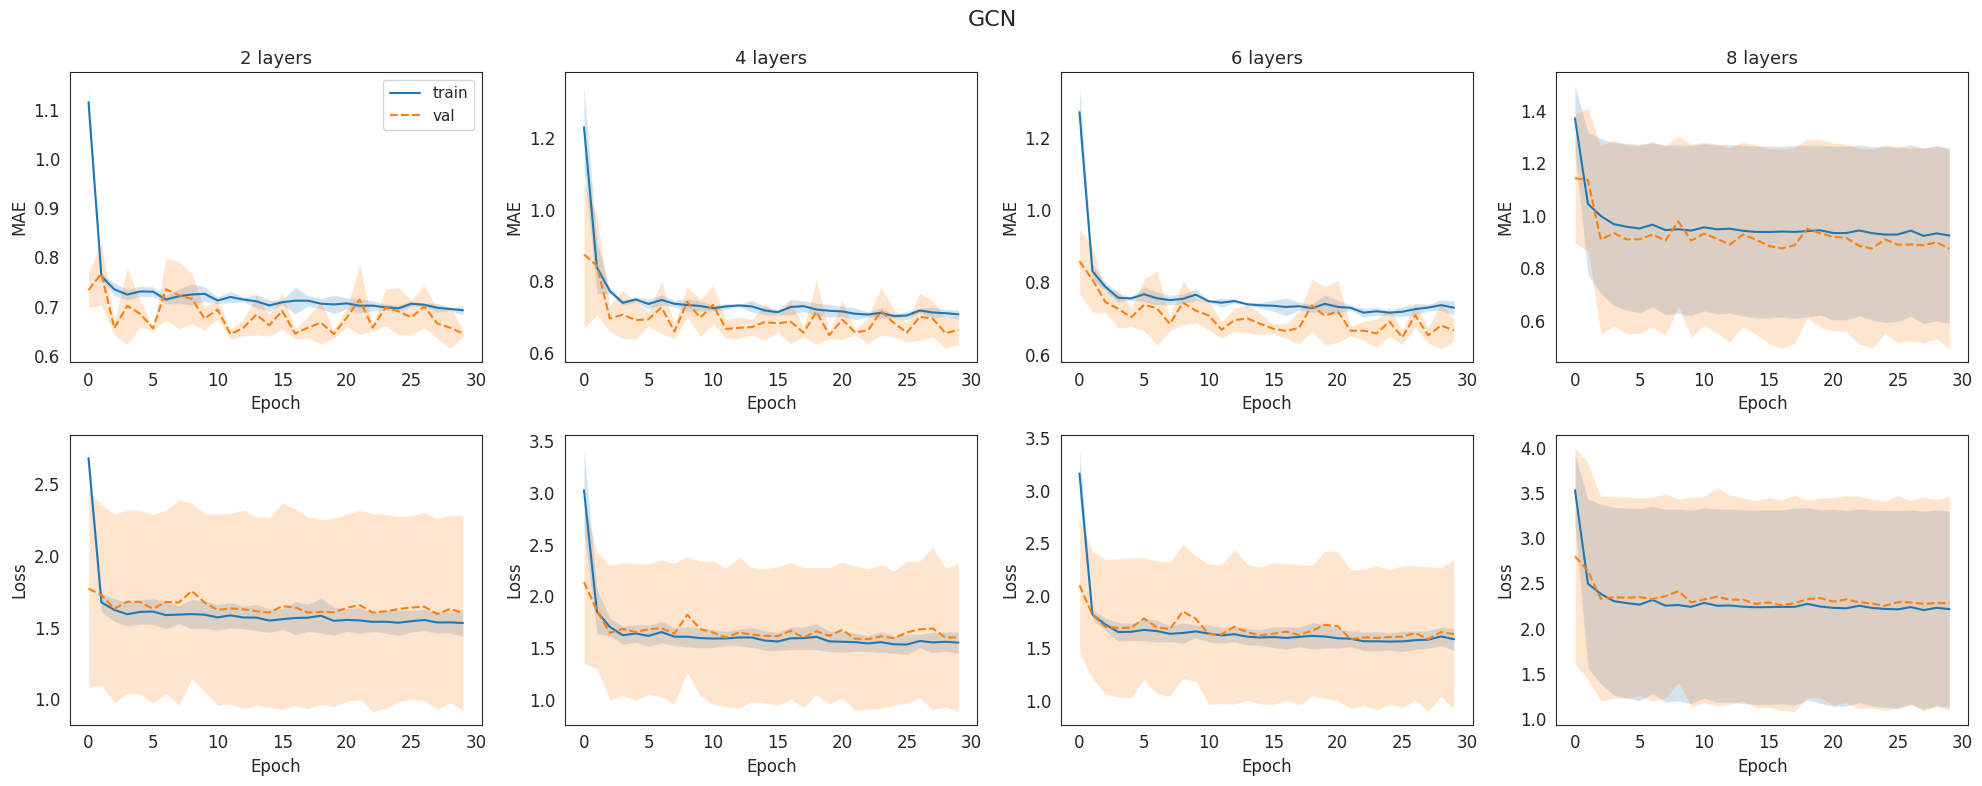

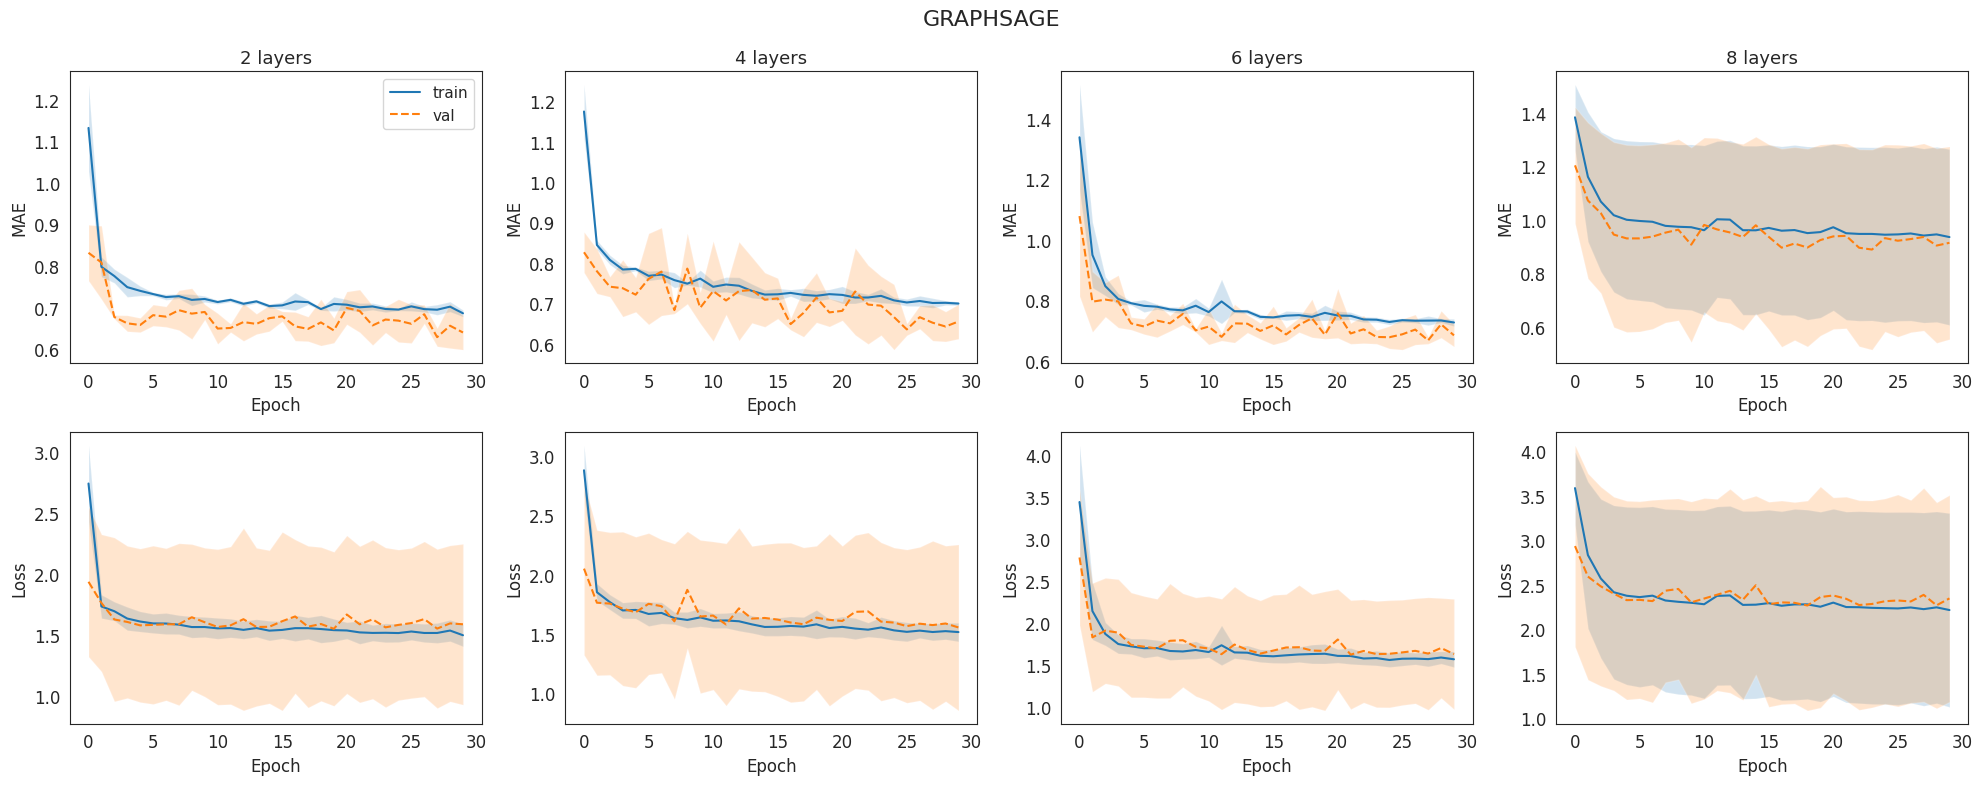

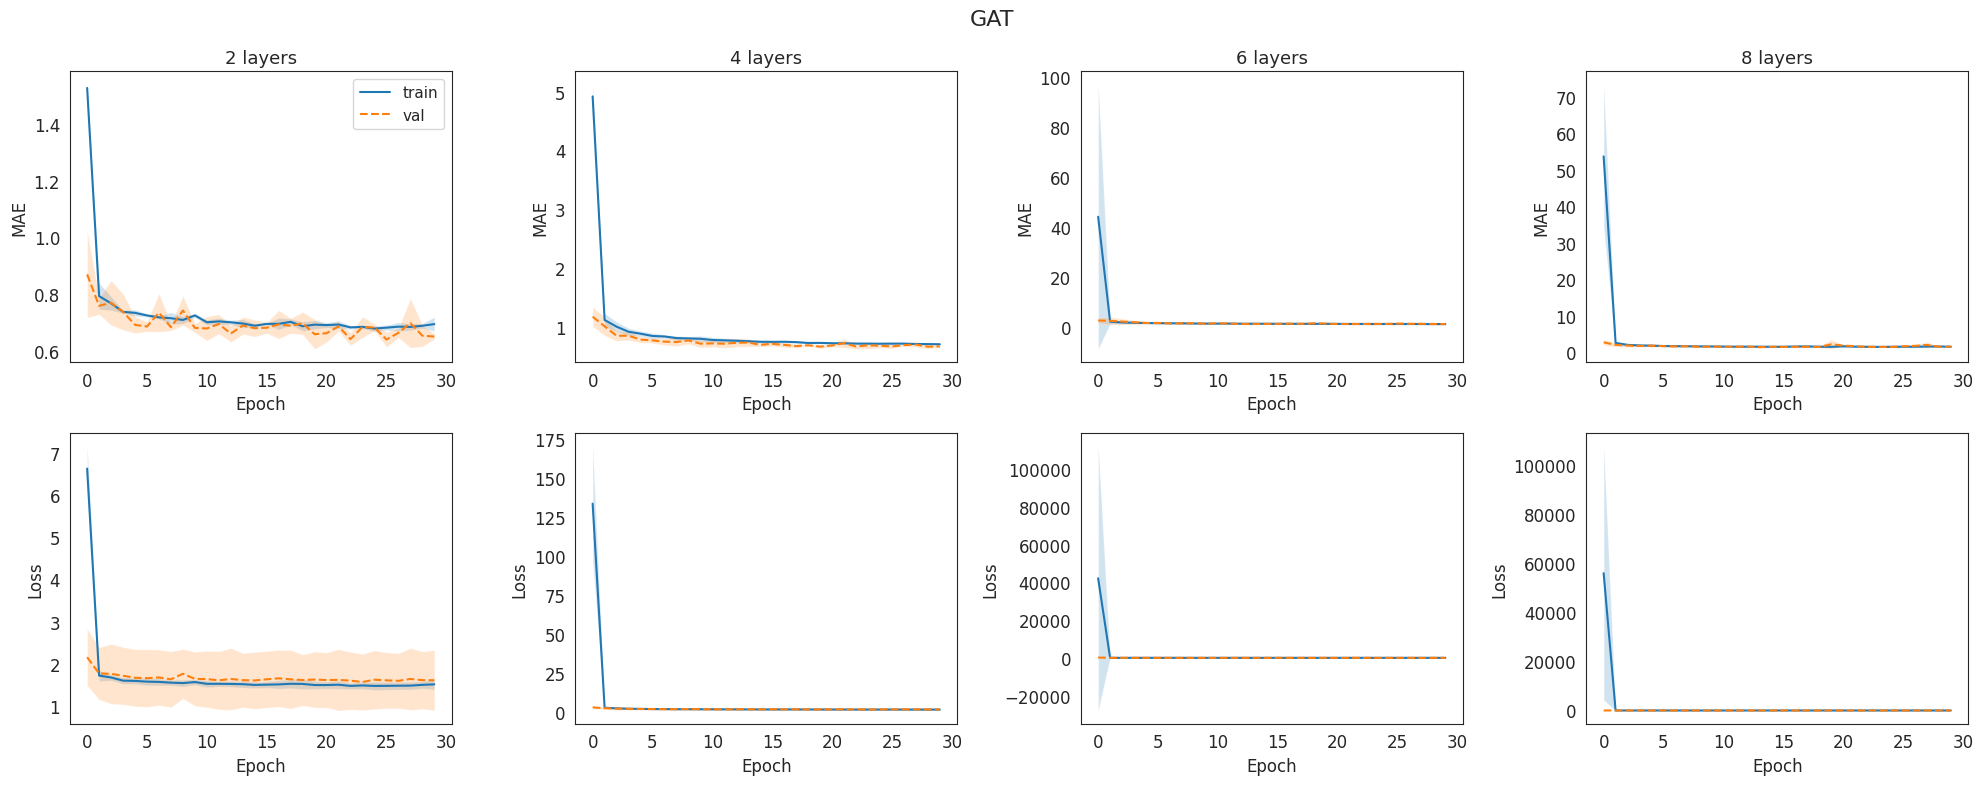

In [7]:
plot_by_model(history, "gcn")
plot_by_model(history, "graphsage")
plot_by_model(history, "gat")

In [8]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

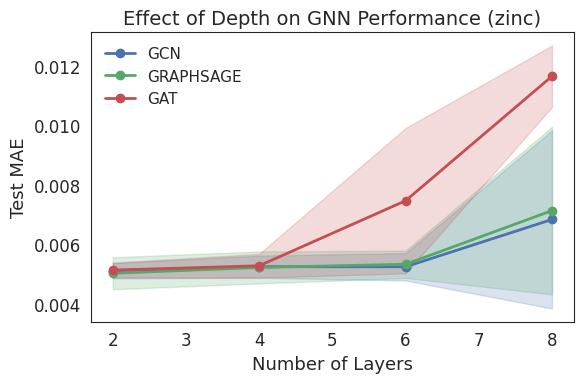

In [9]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    layers = data["layers"]
    mean = np.array(data["mae_mean"])
    std = np.array(data["mae_std"])

    plt.plot(
        layers,
        mean,
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

    # banda de variabilidad (mean ± std)
    plt.fill_between(
        layers,
        mean - std,
        mean + std,
        color=colors[model],
        alpha=0.2
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test MAE")

plt.title("Effect of Depth on GNN Performance (zinc)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/zinc/mae_vs_layers.png", dpi=300)

plt.show()

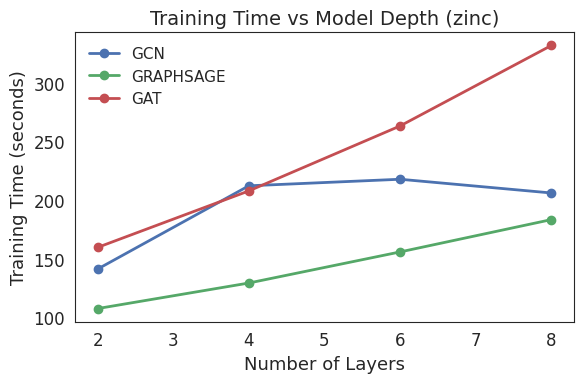

In [10]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth (zinc)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../../results/plots/zinc/time_vs_layers.png", dpi=300)

plt.show()

In [11]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "mae_mean": results[model]["mae_mean"][i],
            "mae_std": results[model]["mae_std"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../../results/tables/zinc/gnn_layer_experiments.csv", index=False)

In [12]:
with open("../../results/tables/zinc/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

with open("../../results/tables/zinc/history.json", "w") as f:
    json.dump(history, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [36]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

print("Average nodes per graph:", np.mean(num_nodes))
print("Minimum nodes per graph:", np.min(num_nodes))
print("Maximun nodes per graph:", np.max(num_nodes))
print("Average edges per graph:", np.mean(num_edges))
print("Minimum edges per graph:", np.min(num_edges))
print("Maximum edges per graph:", np.max(num_edges))

Average nodes per graph: 23.1664
Minimum nodes per graph: 9
Maximun nodes per graph: 37
Average edges per graph: 49.8558
Minimum edges per graph: 16
Maximum edges per graph: 82


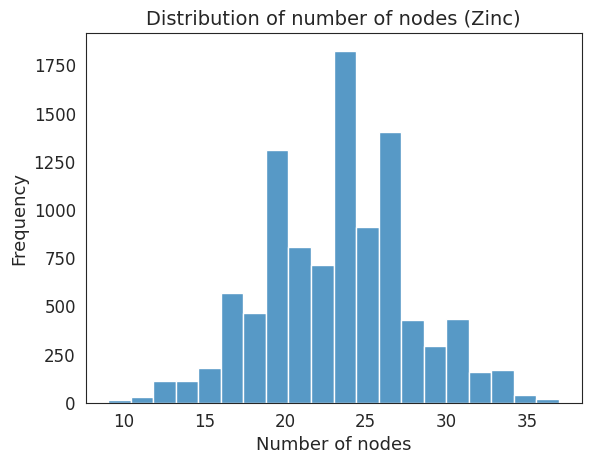

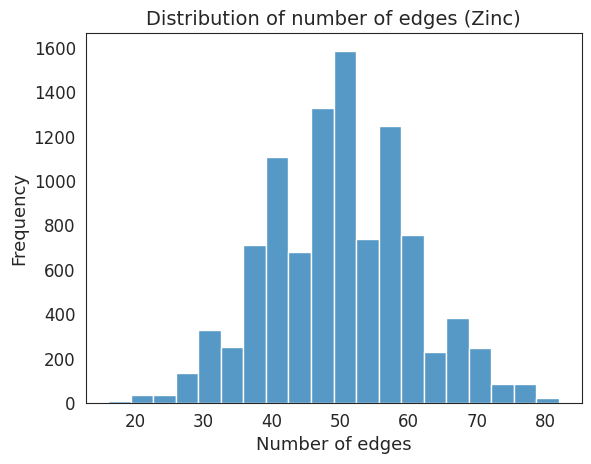

In [37]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

plt.figure()
sns.histplot(num_nodes, bins=20, kde=False)
plt.title("Distribution of number of nodes (Zinc)")
plt.xlabel("Number of nodes")
plt.ylabel("Frequency")
plt.savefig(
    "../../results/plots/zinc/distribution_nodes.png",
    dpi=300
)
plt.show()

plt.figure()
sns.histplot(num_edges, bins=20, kde=False)
plt.title("Distribution of number of edges (Zinc)")
plt.xlabel("Number of edges")
plt.ylabel("Frequency")
plt.savefig(
    "../../results/plots/zinc/distribution_edges.png",
    dpi=300
)
plt.show()

In [7]:
nx_graphs = []

for data in dataset:
    G = to_networkx(data, to_undirected=True)
    nx_graphs.append(G)

print("Converted graphs:", len(nx_graphs))

Converted graphs: 10000


In [8]:
betweenness_values = []

for G in nx_graphs:
    if G.number_of_edges() == 0:
        continue
        
    edge_bet = nx.edge_betweenness_centrality(G)
    betweenness_values.extend(edge_bet.values())

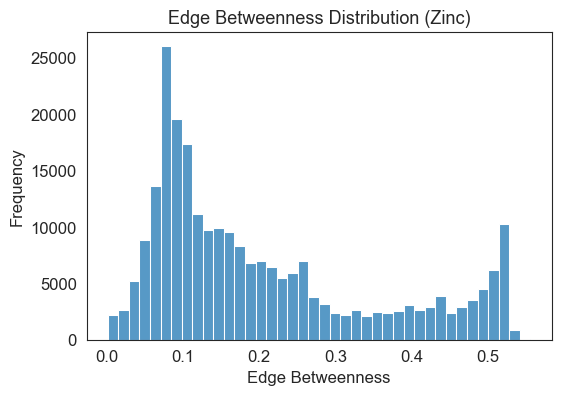

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(betweenness_values, bins=40)

plt.xlabel("Edge Betweenness")
plt.ylabel("Frequency")
plt.title("Edge Betweenness Distribution (Zinc)")
plt.savefig(
    "../../results/plots/zinc/edge_betweenness.png",
    dpi=300
)

plt.show()

The distribution is skewed, with many edges having low betweenness and a few acting as high-traffic connectors. These high-betweenness edges are likely responsible for information bottlenecks in message passing.

In [10]:
top_values = sorted(betweenness_values)[-50:]
top_values = np.sort(top_values)

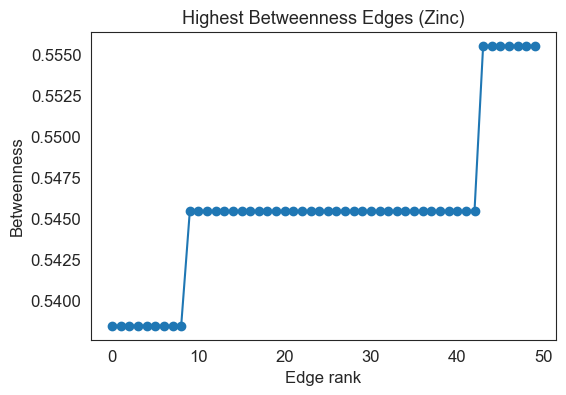

In [11]:
plt.figure(figsize=(6,4))

plt.plot(top_values, marker='o')

plt.xlabel("Edge rank")
plt.ylabel("Betweenness")
plt.title("Highest Betweenness Edges (Zinc)")
plt.savefig(
    "../../results/plots/zinc/highest_betweenness_edges.png",
    dpi=300
)
plt.show()

A small subset of edges dominates the betweenness ranking, showing sharp transitions between tiers of importance. This indicates that a few critical edges control most of the information flow, aligning with over-squashing theory.

In [12]:
"""
Computes per-graph edge betweenness statistics.

Returns:
    dict with:
        - max: list of max betweenness per graph
        - mean: list of mean betweenness per graph
        - p95: list of 95th percentile per graph
"""

max_vals = []
mean_vals = []
p95_vals = []

for data in dataset:

    # convertir a NetworkX
    edge_index = data.edge_index.cpu().numpy()
    G = nx.Graph()
    G.add_edges_from(edge_index.T)

    # betweenness de aristas
    eb = nx.edge_betweenness_centrality(G)

    values = np.array(list(eb.values()))

    if len(values) == 0:
        continue

    max_vals.append(values.max())
    mean_vals.append(values.mean())
    p95_vals.append(np.percentile(values, 95))

stats = {
        "max": max_vals,
        "mean": mean_vals,
        "p95": p95_vals
    }

print("Avg max:", np.mean(stats["max"]))
print("Avg p95:", np.mean(stats["p95"]))

Avg max: 0.5097929939965306
Avg p95: 0.4827295837447419


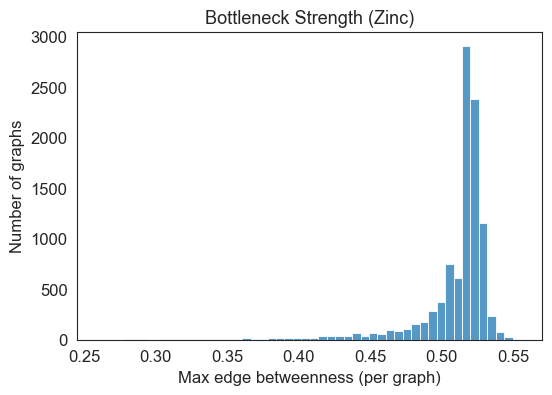

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(stats["max"], bins=50)

plt.xlabel("Max edge betweenness (per graph)")
plt.ylabel("Number of graphs")
plt.title("Bottleneck Strength (Zinc)")
plt.savefig(
    "../../results/plots/zinc/bottleneck_strength.png",
    dpi=300
)
plt.show()

Most graphs exhibit relatively high edge betweenness concentration, indicating the presence of structural bottlenecks. This supports the hypothesis that over-squashing may occur due to limited information flow through critical edges.

In [14]:
def average_khop_growth(graphs, max_k=5):

    growth = []

    for k in range(1, max_k+1):

        sizes = []

        for G in graphs:

            if len(G.nodes()) == 0:
                continue

            node = list(G.nodes())[0]

            nodes = nx.single_source_shortest_path_length(G, node, cutoff=k)

            sizes.append(len(nodes))

        growth.append(np.mean(sizes))

    return growth

In [15]:
khop_growth = average_khop_growth(nx_graphs)

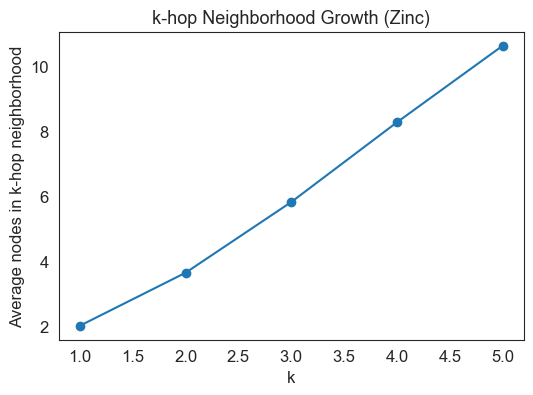

In [16]:
plt.figure(figsize=(6,4))

plt.plot(range(1,6), khop_growth, marker='o')

plt.xlabel("k")
plt.ylabel("Average nodes in k-hop neighborhood")
plt.title("k-hop Neighborhood Growth (Zinc)")
plt.savefig(
    "../../results/plots/zinc/average_nodes_in_khop.png",
    dpi=300
)
plt.show()

The neighborhood size grows steadily with k, indicating moderate receptive field expansion without explosive growth. This suggests deeper GNNs are needed to capture longer-range dependencies in ZINC graphs.